In [1]:
!wget http://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip ml-100k.zip

--2025-11-28 18:57:38--  http://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.grouplens.org/datasets/movielens/ml-100k.zip [following]
--2025-11-28 18:57:39--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip’

ml-100k.zip         100%[===================>]   4.70M  2.69MB/s    in 1.7s    

2025-11-28 18:57:41 (2.69 MB/s) - ‘ml-100k.zip’ saved [4924029/4924029]

Archive:  ml-100k.zip
   creating: ml-100k/
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tensorflow import keras
from keras import layers
import tensorflow as tf
from scipy.sparse import csr_matrix

# Check for GPU availability
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("GPU is available and set up with memory growth.")
else:
    print("No GPU available, falling back to CPU.")

# --- 1. Load the MovieLens 100K Dataset ---
data_path = 'ml-100k/u.data'
column_names = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv(data_path, sep='\t', names=column_names)

# Subsample 70% of the data
# df = df.sample(frac=0.7, random_state=42).reset_index(drop=True)

# Normalize IDs to start from 0
N_USERS = df['user_id'].nunique()
N_ITEMS = df['item_id'].nunique()
df['user_id_norm'] = df['user_id'].astype('category').cat.codes
df['item_id_norm'] = df['item_id'].astype('category').cat.codes

print(f"Total Users: {N_USERS}, Total Items: {N_ITEMS}, Total Ratings: {len(df)}")

# --- 2. Create Sparse User-Item Rating Matrix (R_sparse) ---
rows = df['user_id_norm'].values
cols = df['item_id_norm'].values
vals = df['rating'].values.astype(np.float32)

R_sparse = csr_matrix((vals, (rows, cols)), shape=(N_USERS, N_ITEMS))
print("Sparse R matrix created.")

# --- 3. Construct High-Dimensional Feature Vector X ---
X_features = []
y_labels = []

# One-hot encoders for user + item IDs
user_encoder = OneHotEncoder(sparse_output=False)
item_encoder = OneHotEncoder(sparse_output=False)

user_ids = df['user_id_norm'].values.reshape(-1, 1)
item_ids = df['item_id_norm'].values.reshape(-1, 1)

user_one_hot = user_encoder.fit_transform(user_ids)
item_one_hot = item_encoder.fit_transform(item_ids)

for i, row in df.iterrows():

    u = row['user_id_norm']
    it = row['item_id_norm']
    rating = row['rating']

    # --- Sparse Access (instead of dense R[u] and R[:, i]) ---
    R_u = R_sparse.getrow(u).toarray().ravel()
    R_i = R_sparse.getcol(it).toarray().ravel()

    # One-hot ID vectors
    oh_u = user_one_hot[i]
    oh_i = item_one_hot[i]

    # Full MCFSAE feature vector
    X_ui = np.concatenate([R_u, R_i, oh_u, oh_i])

    X_features.append(X_ui)
    y_labels.append(rating)

# Convert lists to arrays
X = np.array(X_features, dtype=np.float32)
y = np.array(y_labels)

# Free memory
del R_sparse, df

# --- 4. Encode Rating Labels to One-Hot for Softmax ---
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

# --- 5. Split Dataset ---
X_train, X_test, y_train_ohe, y_test_ohe = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# Raw integer labels (not one-hot)
y_train_raw, y_test_raw = train_test_split(
    y, test_size=0.2, random_state=42
)

del X, y

# --- 6. Move data to GPU (if available) ---
with tf.device('/GPU:0' if physical_devices else '/CPU:0'):
    X_train_gpu = tf.constant(X_train, dtype=tf.float32)
    X_test_gpu = tf.constant(X_test, dtype=tf.float32)
    y_train_ohe_gpu = tf.constant(y_train_ohe, dtype=tf.float32)
    y_test_ohe_gpu = tf.constant(y_test_ohe, dtype=tf.float32)

INPUT_DIM = X_train.shape[1]
OUTPUT_CLASSES = y_encoded.shape[1]

del X_train, X_test, y_train_ohe, y_test_ohe


GPU is available and set up with memory growth.
Total Users: 943, Total Items: 1682, Total Ratings: 100000
Sparse R matrix created.


In [ ]:
X_train_gpu.shape

TensorShape([80000, 5250])

In [ ]:
# # --- 1. Define the Stacked AutoEncoder (SAE) Model ---
# # Hyperparameters from the paper's conceptual structure (adapted for 100K)
# ENCODING_DIM = 20  # The bottleneck dimension (Yk in the paper)
# HIDDEN_LAYER_1 = 1000
# HIDDEN_LAYER_2 = 100

# def build_sae(input_dim):
#     # Encoder
#     input_layer = keras.Input(shape=(input_dim,), name='input_layer')

#     # Encoder Layers
#     encoded = layers.Dense(HIDDEN_LAYER_1, activation='linear')(input_layer)
#     encoded = layers.Dense(HIDDEN_LAYER_2, activation='linear')(encoded)

#     # Bottleneck Layer (Latent Feature Yk)
#     encoded = layers.Dense(ENCODING_DIM, activation='linear', name='latent_features')(encoded)

#     # Decoder Layers
#     decoded = layers.Dense(HIDDEN_LAYER_2, activation='linear')(encoded)
#     decoded = layers.Dense(HIDDEN_LAYER_1, activation='linear')(decoded)

#     # Output Layer (Reconstruction)
#     output_layer = layers.Dense(input_dim, activation='linear', name='reconstruction_output')(decoded)

#     # Compile the full AutoEncoder
#     autoencoder = keras.Model(input_layer, output_layer)
#     autoencoder.compile(optimizer='adam', loss='mae')

#     # Encoder Model (for feature extraction)
#     encoder = keras.Model(input_layer, encoded)

#     return autoencoder, encoder

# sae_model, encoder_model = build_sae(INPUT_DIM)

# # --- 2. Train the SAE Model (Feature Learning/Pre-training) ---
# print("\n--- Training Stacked AutoEncoder (SAE) for Feature Reduction ---")
# # SAE trains to reconstruct its input (X -> X)
# # Use a small number of epochs for demonstration
# history_sae = sae_model.fit(X_train_gpu, X_train_gpu,
#               epochs=20,
#               batch_size=256,
#               shuffle=True,
#               validation_data=(X_test_gpu, X_test_gpu),
#               verbose=0)

# # --- 3. Extract Latent Features (Yk) ---
# # Yk is the low-dimensional representation of X, used as input for the Softmax classifier
# # encoder_model.predict will output a tf.Tensor if input is tf.Tensor
# Yk_train = encoder_model.predict(X_train_gpu)
# Yk_test = encoder_model.predict(X_test_gpu)

# print(f"Original Feature Dimension: {INPUT_DIM}")
# print(f"Latent Feature Dimension (Yk): {Yk_train.shape[1]}")

In [3]:
# --- 1. Layer-by-Layer Training for Stacked AutoEncoder (SAE) ---

# Hyperparameters (unchanged)
ENCODING_DIM = 20
HIDDEN_LAYER_1 = 1000
HIDDEN_LAYER_2 = 100

# ====== PRETRAIN LAYER 1 ======
print("\n--- Pretraining Layer 1 ---")

input_layer = keras.Input(shape=(INPUT_DIM,))
h1 = layers.Dense(HIDDEN_LAYER_1, activation="tanh")(input_layer)
out1 = layers.Dense(INPUT_DIM, activation="tanh")(h1)

auto1 = keras.Model(input_layer, out1)
auto1.compile(optimizer="adam", loss="mae")

history_a1 = auto1.fit(X_train_gpu, X_train_gpu,
          epochs=50, batch_size=256,
          shuffle=True,
          validation_data=(X_test_gpu, X_test_gpu),
          verbose=0)

# Extract first hidden layer
model_h1 = keras.Model(input_layer, h1)
H1_train = model_h1.predict(X_train_gpu)
H1_test = model_h1.predict(X_test_gpu)


# ====== PRETRAIN LAYER 2 ======
print("\n--- Pretraining Layer 2 ---")

input_h1 = keras.Input(shape=(HIDDEN_LAYER_1,))
h2 = layers.Dense(HIDDEN_LAYER_2, activation="tanh")(input_h1)
out2 = layers.Dense(HIDDEN_LAYER_1, activation="tanh")(h2)

auto2 = keras.Model(input_h1, out2)
auto2.compile(optimizer="adam", loss="mae")

history_a2 = auto2.fit(H1_train, H1_train,
          epochs=50, batch_size=256,
          shuffle=True,
          validation_data=(H1_test, H1_test),
          verbose=0)

# Extract layer 2
model_h2 = keras.Model(input_h1, h2)
H2_train = model_h2.predict(H1_train)
H2_test = model_h2.predict(H1_test)


# ====== PRETRAIN BOTTLENECK (ENCODING LAYER) ======
print("\n--- Pretraining Bottleneck Layer ---")

input_h2 = keras.Input(shape=(HIDDEN_LAYER_2,))
bottleneck = layers.Dense(ENCODING_DIM, activation="tanh")(input_h2)
out3 = layers.Dense(HIDDEN_LAYER_2, activation="tanh")(bottleneck)

auto3 = keras.Model(input_h2, out3)
auto3.compile(optimizer="adam", loss="mae")

history_a3 = auto3.fit(H2_train, H2_train,
          epochs=50, batch_size=256,
          shuffle=True,
          validation_data=(H2_test, H2_test),
          verbose=0)

# Extract bottleneck output (Yk)
encoder_only = keras.Model(input_h2, bottleneck)
Yk_train = encoder_only.predict(H2_train)
Yk_test = encoder_only.predict(H2_test)


print("\n--- Building Final SAE with Pretrained Weights ---")

# Full input
full_input = keras.Input(shape=(INPUT_DIM,))

# Rebuild encoder layers
e1 = layers.Dense(HIDDEN_LAYER_1, activation="tanh")
e2 = layers.Dense(HIDDEN_LAYER_2, activation="tanh")
e3 = layers.Dense(ENCODING_DIM, activation="tanh", name="latent_features")

# --- IMPORTANT: Build layers with a dummy forward pass ---
_ = e1(full_input)
_ = e2(e1(full_input))
_ = e3(e2(e1(full_input)))   # NOW layers have weights

# --- Load pretrained weights properly ---
e1.set_weights(model_h1.layers[1].get_weights())     # From first autoencoder
e2.set_weights(model_h2.layers[1].get_weights())     # From second autoencoder
e3.set_weights(auto3.layers[1].get_weights())        # From bottleneck autoencoder

# Encode using pretrained weights
z = e3(e2(e1(full_input)))

# Rebuild decoder (fresh weights, as usual in greedy SAE)
d3 = layers.Dense(HIDDEN_LAYER_2, activation="tanh")
d2 = layers.Dense(HIDDEN_LAYER_1, activation="tanh")
d1 = layers.Dense(INPUT_DIM, activation="linear", name="reconstruction_output")

decoded = d1(d2(d3(z)))
sae_model = keras.Model(full_input, decoded)

sae_model.compile(optimizer="adam", loss="mse")

print("\n--- Fine-Tuning Full SAE ---")
history_sae = sae_model.fit(
    X_train_gpu, X_train_gpu,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_gpu, X_test_gpu),
    verbose=0
)

# Extract final encoder
encoder_model = keras.Model(full_input, z)


# --- 4. Extract Latent Features (Yk) Using Final Encoder ---
print("\n--- Extracting Final Latent Features (Yk) ---")

Yk_train = encoder_model.predict(X_train_gpu)
Yk_test = encoder_model.predict(X_test_gpu)

print(f"Final Yk_train shape: {Yk_train.shape}")
print(f"Final Yk_test shape:  {Yk_test.shape}")




--- Pretraining Layer 1 ---
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

--- Pretraining Layer 2 ---
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Pretraining Bottleneck Layer ---
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

--- Building Final SAE with Pretrained Weights ---

--- Fine-Tuning Full SAE ---

--- Extracting Final Latent Features (Yk) ---
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Final Yk_train shape: (80000, 20)
Final Yk_test shape:  (20000, 20)


In [5]:
# --- 1. Define the Softmax Classification Model ---
def build_softmax_classifier(input_dim, output_classes):
    model = keras.Sequential([
        # Input is the latent feature vector Yk
        keras.Input(shape=(input_dim,)),
        # Add a dense hidden layer (optional, but common in deep models)
        layers.Dense(32, activation='relu'),
        # Output layer with Softmax for multi-class classification (5 rating classes)
        layers.Dense(output_classes, activation='softmax', name='softmax_output')
          # layers.Dense(output_classes, input_shape=(input_dim,) ,activation='softmax', name='softmax_classification_layer')
    ])

    # Loss: categorical crossentropy for multi-class classification
    # Metrics: Accuracy (for classification) and MAE/RMSE (for regression-like evaluation)
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

softmax_model = build_softmax_classifier(ENCODING_DIM, OUTPUT_CLASSES)

# --- 2. Train the Softmax Model ---
print("\n--- Training Softmax Classifier for Rating Prediction ---")
history_soft = softmax_model.fit(Yk_train, y_train_ohe_gpu,
                            epochs=50,
                            batch_size=256,
                            validation_data=(Yk_test, y_test_ohe_gpu),
                            verbose=0)

# --- 3. Evaluate and Predict ---
loss, accuracy = softmax_model.evaluate(Yk_test, y_test_ohe_gpu, verbose=0)

# Make predictions on the test set
predicted_ohe = softmax_model.predict(Yk_test)
# Convert one-hot predictions back to integer ratings (1-5)
predicted_ratings = np.argmax(predicted_ohe, axis=1) + 1 # Convert tf.Tensor to numpy for argmax

print(f"\nMCFSAE Model Evaluation on Test Set:")
print(f"Classification Accuracy: {accuracy:.4f}")

# Example of a rating prediction for the first 5 test samples
print("\nExample Predictions (Predicted vs. Actual Rating):")
for i in range(5):
    actual = y_test_raw[i]
    predicted = predicted_ratings[i]
    print(f"Sample {i+1}: Predicted={predicted}, Actual={actual}")


--- Training Softmax Classifier for Rating Prediction ---
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

MCFSAE Model Evaluation on Test Set:
Classification Accuracy: 0.3991

Example Predictions (Predicted vs. Actual Rating):
Sample 1: Predicted=4, Actual=4
Sample 2: Predicted=4, Actual=3
Sample 3: Predicted=4, Actual=4
Sample 4: Predicted=4, Actual=2
Sample 5: Predicted=4, Actual=2


In [6]:
from sklearn.metrics import mean_absolute_error

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test_raw, predicted_ratings)

print(f"Mean Absolute Error (MAE) on Test Set: {mae:.4f}")

Mean Absolute Error (MAE) on Test Set: 0.7635


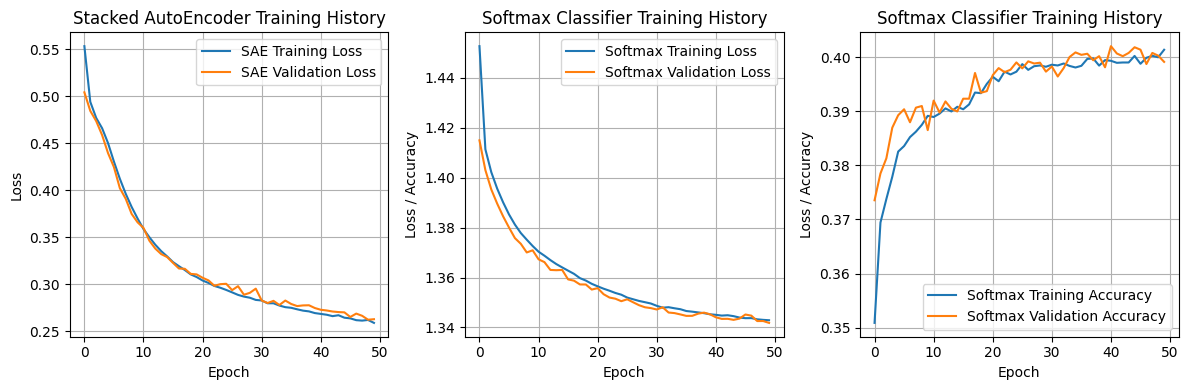

In [7]:
import matplotlib.pyplot as plt

# Plot SAE history
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history_sae.history['loss'], label='SAE Training Loss')
plt.plot(history_sae.history['val_loss'], label='SAE Validation Loss')
plt.title('Stacked AutoEncoder Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Softmax history
plt.subplot(1, 3, 2)
plt.plot(history_soft.history['loss'], label='Softmax Training Loss')
plt.plot(history_soft.history['val_loss'], label='Softmax Validation Loss')
plt.title('Softmax Classifier Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss / Accuracy')
plt.legend()
plt.grid(True)

# Plot Softmax history
plt.subplot(1, 3, 3)
plt.plot(history_soft.history['accuracy'], label='Softmax Training Accuracy')
plt.plot(history_soft.history['val_accuracy'], label='Softmax Validation Accuracy')
plt.title('Softmax Classifier Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss / Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

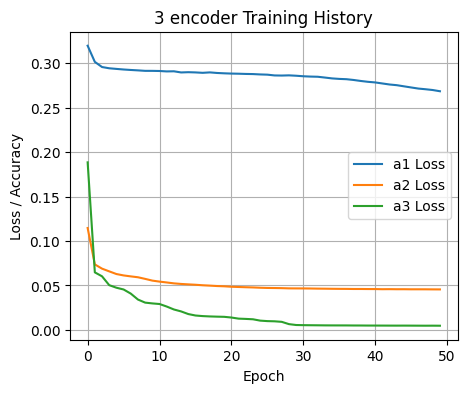

In [8]:
plt.figure(figsize=(5, 4))

plt.plot(history_a1.history['loss'], label='a1 Loss')
plt.plot(history_a2.history['loss'], label='a2 Loss')
plt.plot(history_a3.history['loss'], label='a3 Loss')
plt.title('3 encoder Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss / Accuracy')
plt.legend()
plt.grid(True)
plt.show()